In [1]:
import sys
from pathlib import Path

# add src directory to python path
sys.path.append(str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
from sklearn import __version__ as sk_ver
print('sklearn:', sk_ver)

from random_forest import tools

sklearn: 1.7.2


#### Phase 01 : Import data

In [2]:
pre_processed = pd.read_parquet('../src/data/pre_processed/features.parquet')

In [3]:
pre_processed.head(10)

,Elo_diff,Elo_mean,N_min,elo_surface_diff,elo_effective_diff,spec_diff,surface_exp_min,log_pts_diff,log_rank_diff,Surface_Clay,Surface_Grass,Surface_Hard,Best_of_5,Winner
0,0.000000,1500.000000,0.0,0.000000,0.000000,0.000000,0,NaN,0.585902,0.0,0.0,1.0,0,0
1,0.000000,1500.000000,0.0,0.000000,0.000000,0.000000,0,NaN,0.659246,0.0,0.0,1.0,0,0
2,0.000000,1500.000000,0.0,0.000000,0.000000,0.000000,0,NaN,-0.037041,0.0,0.0,1.0,0,1
3,0.000000,1500.000000,0.0,0.000000,0.000000,0.000000,0,NaN,0.843429,0.0,0.0,1.0,0,1
4,0.000000,1500.000000,0.0,0.000000,0.000000,0.000000,0,NaN,-1.749200,0.0,0.0,1.0,0,0
5,0.000000,1500.000000,0.0,0.000000,0.000000,0.000000,0,NaN,1.196251,0.0,0.0,1.0,0,0
6,-65.663195,1467.168402,0.0,-16.000000,-8.200000,-0.002000,0,NaN,2.151762,0.0,0.0,1.0,0,1
7,-77.927462,1461.036269,0.0,-16.377554,-8.393496,-0.002047,0,NaN,-2.095971,0.0,0.0,1.0,0,1
8,0.000000,1500.000000,0.0,0.000000,0.000000,0.000000,0,NaN,0.116724,0.0,0.0,1.0,0,0
9,-6.783409,1503.391704,0.0,0.402330,0.211223,0.000101,0,NaN,0.240054,0.0,0.0,1.0,0,0


#### Phase 02: Split train/test

In [4]:
y_name = 'Winner'
X_train, X_test, y_train, y_test = tools.split_data(pre_processed, y_name)

In [5]:
print('X train shape:', X_train.shape)
print('X test  shape:', X_test .shape)
print('y train shape:', y_train.shape)
print('y test  shape:', y_test .shape)

X train shape: (54705, 13)
X test  shape: (13677, 13)
y train shape: (54705,)
y test  shape: (13677,)


#### Phase 03 : Train

In [6]:
from random_forest.model import SymmetricForest
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

param_grid = {
    'max_depth':        [6, 10, 14, None],
    'min_samples_leaf': [20, 50, 100, 200],
    'max_features':     [0.3, 0.5, 'sqrt'],
}

# X, y must be sorted chronologically for TimeSeriesSplit to be honest
cv = TimeSeriesSplit(n_splits=5)

search = GridSearchCV(
    estimator=SymmetricForest(),
    param_grid=param_grid,
    scoring={'logloss': 'neg_log_loss', 'auc': 'roc_auc'},
    refit='logloss',                # LogLoss is the primary objective
    cv=cv,
    n_jobs=1,                       # forest already uses all cores
    verbose=2,
    return_train_score=True,
)

In [7]:
search.fit(X_train, y_train)

print(f"best params : {search.best_params_}")
print(f"cv logloss  : {-search.best_score_:.4f}")

best = search.best_estimator_

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END .max_depth=6, max_features=0.3, min_samples_leaf=20; total time=   2.4s
[CV] END .max_depth=6, max_features=0.3, min_samples_leaf=20; total time=   5.5s
[CV] END .max_depth=6, max_features=0.3, min_samples_leaf=20; total time=   7.7s
[CV] END .max_depth=6, max_features=0.3, min_samples_leaf=20; total time=   9.5s
[CV] END .max_depth=6, max_features=0.3, min_samples_leaf=20; total time=  12.7s
[CV] END .max_depth=6, max_features=0.3, min_samples_leaf=50; total time=   2.4s
[CV] END .max_depth=6, max_features=0.3, min_samples_leaf=50; total time=   4.5s
[CV] END .max_depth=6, max_features=0.3, min_samples_leaf=50; total time=   7.3s
[CV] END .max_depth=6, max_features=0.3, min_samples_leaf=50; total time=  15.3s
[CV] END .max_depth=6, max_features=0.3, min_samples_leaf=50; total time=  16.0s
[CV] END max_depth=6, max_features=0.3, min_samples_leaf=100; total time=   2.5s
[CV] END max_depth=6, max_features=0.3, min_sam

#### Phase 05 : Evaluation

In [10]:
from sklearn.metrics import log_loss, roc_auc_score, brier_score_loss, accuracy_score

p_test = best.predict_proba(X_test)[:, 1]
print(f"test logloss: {log_loss(y_test, p_test)}")
print(f"test auc    : {roc_auc_score(y_test, p_test)}")
print(f"Test Brier  : {brier_score_loss(y_test, p_test)}")
print(f"Test Acc    : {accuracy_score(y_test, p_test > 0.5)}")

test logloss: 0.6146378352346374
test auc    : 0.7167730615761563
Test Brier  : 0.21380891055781878
Test Acc    : 0.6508737296190685


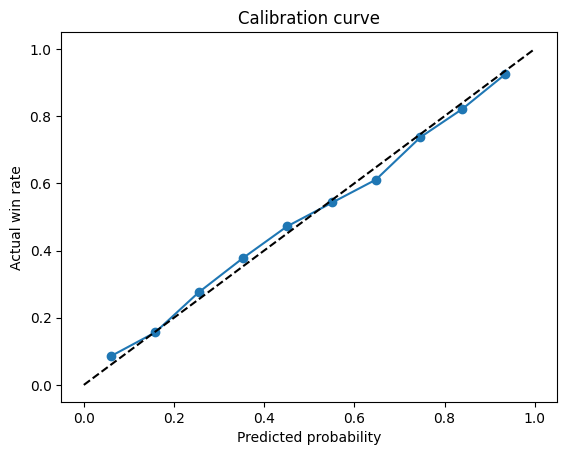

In [11]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, p_test, n_bins=10)
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Predicted probability'); plt.ylabel('Actual win rate')
plt.title('Calibration curve')
plt.show()